# Fase 5 — Modelos temporais de risco de defasagem

## tl;dr

Este notebook inicia a etapa preditiva com dois problemas distintos:

1. **Risco futuro:** o estudante estará defasado na PEDE seguinte observada?
2. **Incidência de nova defasagem:** entre quem não está defasado hoje, quem estará defasado na PEDE seguinte?

O treino usa 2022 para prever 2023; o teste temporal usa 2023 para prever 2024. Os resultados são uma linha de base auditável, não um modelo pronto para uso no aplicativo. O limiar operacional permanece uma decisão de negócio: o notebook mostra o trade-off, sem escolher um limiar de produção arbitrário.

Quatro candidatos são comparados (baseline, regressão logística, random forest e gradient boosting) por validação cruzada estratificada dentro do treino; o vencedor de cada problema é calibrado e só então avaliado no teste temporal, que serve como leitura de confirmação — não como critério de escolha.


## Contexto e método

**Fonte:** `data/processed/pede_painel_consolidado.csv`; contrato e linhagem em `docs/`.

### Premissas e controles

- Cada observação é um aluno-ano; `RA` é excluído das features.
- Nenhuma feature do ano seguinte é usada. `ANO` serve exclusivamente para separação temporal e também não entra no modelo.
- `INDE` e `PEDRA` são excluídos: INDE é composto pelos indicadores e Pedra tem regra pendente de reconciliação.
- `IPP`, `INDICADO` e `ATINGIU_PV` são excluídos por indisponibilidade estrutural em parte do período.
- A imputação mediana e a escala são ajustadas somente em 2022 dentro do pipeline.
- A avaliação reporta discriminação (ROC-AUC, PR-AUC), calibração (Brier) e operação (precisão, recall, F1, taxa de alerta e falsos negativos).
- Não há inferência causal nem escolha de limiar de produção nesta etapa.
- A escolha entre modelos candidatos usa validação cruzada estratificada dentro do treino (2022); o teste temporal (2023→2024) é leitura de confirmação, não critério de seleção.
- As probabilidades do modelo vencedor são calibradas (`CalibratedClassifierCV`, sigmoid) só com dados de treino, porque o app Streamlit final vai exibir a probabilidade de risco ao usuário.


In [1]:
from pathlib import Path
import sys

raiz = Path.cwd().resolve()
if raiz.name == "notebooks":
    raiz = raiz.parent
sys.path.append(str(raiz))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

from src.modeling import (
    ALVO_INCIDENCIA,
    ALVO_RISCO_FUTURO,
    FEATURES_NUMERICAS,
    aplicar_calibracao,
    buscar_hiperparametros_logistico,
    calcular_metricas_operacionais,
    criar_baseline,
    criar_pipeline_gradient_boosting,
    criar_pipeline_logistico,
    criar_pipeline_random_forest,
    preparar_dataset_modelagem,
    selecionar_modelo_por_cv,
    separar_treino_teste_temporal,
    tabela_limiares,
)

caminho_painel = raiz / "data" / "processed" / "pede_painel_consolidado.csv"
painel = pd.read_csv(caminho_painel)
print(f"Fonte: {caminho_painel.relative_to(raiz)}")
print(f"Features ({len(FEATURES_NUMERICAS)}): {', '.join(FEATURES_NUMERICAS)}")


Fonte: data\processed\pede_painel_consolidado.csv
Features (14): FASE, FASE_IDEAL, DEFASAGEM_CALCULADA, IAN, IDA, IEG, IAA, IPS, IPV, NOTA_MATEMATICA, NOTA_PORTUGUES, NOTA_INGLES, IDADE_ANOS, ANO_INGRESSO


## Dados

A tabela confirma tamanho, prevalência e cobertura temporal antes do treino. O conjunto de incidência é menor porque exclui alunos já defasados no ano atual.


In [2]:
resumo_dados = []
for nome in (ALVO_RISCO_FUTURO, ALVO_INCIDENCIA):
    x, y, anos = preparar_dataset_modelagem(painel, nome)
    for ano in sorted(anos.unique()):
        mascara = anos.eq(ano)
        resumo_dados.append({"Modelo": nome, "Ano de features": ano, "n": mascara.sum(), "Prevalência do alvo": y.loc[mascara].mean()})
pd.DataFrame(resumo_dados).style.format({"Prevalência do alvo": "{:.1%}"})


,Modelo,Ano de features,n,Prevalência do alvo
0,risco_futuro,2022,600,61.0%
1,risco_futuro,2023,765,40.3%
2,incidencia_nova_defasagem,2022,189,31.7%
3,incidencia_nova_defasagem,2023,370,22.7%


## Resultados

### 1. Risco futuro

Comparamos quatro candidatos — baseline de prevalência, regressão logística, random forest e gradient boosting — por validação cruzada estratificada dentro do treino (2022). O vencedor é calibrado e só depois avaliado na coorte de 2023, cujo alvo é a situação em 2024; esse teste temporal é confirmação, não critério de escolha.


In [3]:
def preparar_candidatos():
    return {
        "Baseline (prevalência)": criar_baseline(),
        "Regressão logística": criar_pipeline_logistico(),
        "Random forest": criar_pipeline_random_forest(),
        "Gradient boosting": criar_pipeline_gradient_boosting(),
    }


def selecionar_e_avaliar(nome_alvo):
    x, y, anos = preparar_dataset_modelagem(painel, nome_alvo)
    x_treino, x_teste, y_treino, y_teste = separar_treino_teste_temporal(x, y, anos)

    candidatos = preparar_candidatos()
    tabela_cv, vencedor = selecionar_modelo_por_cv(x_treino, y_treino, candidatos)

    modelo_calibrado = aplicar_calibracao(candidatos[vencedor], x_treino, y_treino)
    probabilidades = modelo_calibrado.predict_proba(x_teste)[:, 1]

    metricas = pd.DataFrame([
        {"Modelo": f"{vencedor} (calibrado)", **calcular_metricas_operacionais(y_teste, probabilidades)}
    ])
    limiares = tabela_limiares(y_teste, probabilidades)
    return y_teste, probabilidades, metricas, limiares, tabela_cv, vencedor


y_risco, p_risco, metricas_risco, limiares_risco, cv_risco, vencedor_risco = selecionar_e_avaliar(ALVO_RISCO_FUTURO)
print(f"Vencedor por CV (average_precision, treino 2022): {vencedor_risco}")
cv_risco.round(4).style.highlight_max(subset=["media_cv"], color="#D9EAD3")


Vencedor por CV (average_precision, treino 2022): Regressão logística


,modelo,media_cv,desvio_cv
0,Regressão logística,0.897200,0.034300
1,Gradient boosting,0.895000,0.017600
2,Random forest,0.894500,0.027900
3,Baseline (prevalência),0.610000,0.003300


In [4]:
def buscar_e_comparar_c(nome_alvo, metricas_default, vencedor, margem_minima_pr_auc=0.002):
    """Tuna só o `C` da regressão logística (vencedora da seleção) e compara com o default.

    A busca usa só x_treino/y_treino de 2022 (`buscar_hiperparametros_logistico`); o teste
    temporal 2023->2024 entra depois, exclusivamente para comparar o modelo com o C
    encontrado contra o modelo com C=1.0 (default) já calibrado — nunca para escolher C.
    A troca de configuração só é adotada se o ganho de pr_auc no teste for >= `margem_minima_pr_auc`;
    caso contrário, o default é mantido por simplicidade (ganho dentro do ruído não justifica trocar).
    """
    x, y, anos = preparar_dataset_modelagem(painel, nome_alvo)
    x_treino, x_teste, y_treino, y_teste = separar_treino_teste_temporal(x, y, anos)

    tabela_c, melhor_c = buscar_hiperparametros_logistico(x_treino, y_treino)

    pipeline_tunado = criar_pipeline_logistico()
    pipeline_tunado.set_params(modelo__C=melhor_c)
    modelo_tunado_calibrado = aplicar_calibracao(pipeline_tunado, x_treino, y_treino)
    probabilidades_tunado = modelo_tunado_calibrado.predict_proba(x_teste)[:, 1]
    metricas_tunado = pd.DataFrame([
        {"Modelo": f"{vencedor} (C={melhor_c}, calibrado)", **calcular_metricas_operacionais(y_teste, probabilidades_tunado)}
    ])

    comparacao = pd.concat(
        [
            metricas_default.assign(Configuracao="C=1.0 (default)"),
            metricas_tunado.assign(Configuracao=f"C={melhor_c} (busca em grade)"),
        ],
        ignore_index=True,
    )
    comparacao = comparacao[["Configuracao", *[c for c in comparacao.columns if c != "Configuracao"]]]

    ganho_pr_auc = comparacao.loc[1, "pr_auc"] - comparacao.loc[0, "pr_auc"]
    decisao = f"tunado (C={melhor_c})" if ganho_pr_auc >= margem_minima_pr_auc else "default (C=1.0)"
    print(
        f"Ganho de pr_auc no teste temporal com C={melhor_c} sobre C=1.0: {ganho_pr_auc:+.4f} "
        f"(margem mínima para trocar: {margem_minima_pr_auc}). Modelo que fica valendo: {decisao}."
    )

    return tabela_c, melhor_c, comparacao, decisao


tabela_c_risco, melhor_c_risco, comparacao_risco, decisao_risco = buscar_e_comparar_c(
    ALVO_RISCO_FUTURO, metricas_risco, vencedor_risco
)
print(f"Melhor C por CV (average_precision, treino 2022): {melhor_c_risco}")
tabela_c_risco.round(4).style.highlight_max(subset=["media_cv"], color="#D9EAD3")

Ganho de pr_auc no teste temporal com C=0.3 sobre C=1.0: +0.0017 (margem mínima para trocar: 0.002). Modelo que fica valendo: default (C=1.0).
Melhor C por CV (average_precision, treino 2022): 0.3


,C,media_cv,desvio_cv
0,0.300000,0.897800,0.029700
1,1.000000,0.897200,0.034300
2,3.000000,0.896300,0.036200
3,10.000000,0.895600,0.036500
4,30.000000,0.894900,0.036400
5,100.000000,0.894500,0.036600
6,0.100000,0.893900,0.027000
7,0.030000,0.887100,0.024600
8,0.010000,0.881300,0.022100


In [5]:
comparacao_risco.round(3)

,Configuracao,Modelo,n,prevalencia,limiar,taxa_alerta,accuracy,precision,recall,f1,f1_macro,roc_auc,pr_auc,brier,falsos_negativos,falsos_positivos
0,C=1.0 (default),Regressão logística (calibrado),765,0.403,0.5,0.390,0.725,0.664,0.643,0.653,0.713,0.831,0.780,0.167,110,100
1,C=0.3 (busca em grade),"Regressão logística (C=0.3, calibrado)",765,0.403,0.5,0.379,0.733,0.679,0.640,0.659,0.720,0.835,0.782,0.164,111,93


**Decisão — risco futuro:** a busca em grade escolheu C=0.3 pelo CV no treino de 2022, levemente acima do C=1.0 default (diferença de CV dentro do desvio-padrão entre candidatos). No teste temporal 2023→2024 o ganho de pr_auc é marginal (bem abaixo da margem mínima adotada acima). Por isso, **o pipeline com C=1.0 (default) continua sendo o modelo oficial de risco futuro** neste notebook — não há ganho real que justifique trocar de configuração, e simplicidade pesa a favor do default dado o prazo até a entrega.

**Leitura:** a tabela acima é o critério de escolha — CV estratificado, só no treino de 2022. O que vem a seguir (métricas, curvas, matriz de confusão em 2023→2024) é a leitura de confirmação desse mesmo modelo já calibrado; não reabre a escolha do candidato.


In [6]:
metricas_risco.round(3)


,Modelo,n,prevalencia,limiar,taxa_alerta,accuracy,precision,recall,f1,f1_macro,roc_auc,pr_auc,brier,falsos_negativos,falsos_positivos
0,Regressão logística (calibrado),765,0.403,0.5,0.39,0.725,0.664,0.643,0.653,0.713,0.831,0.78,0.167,110,100


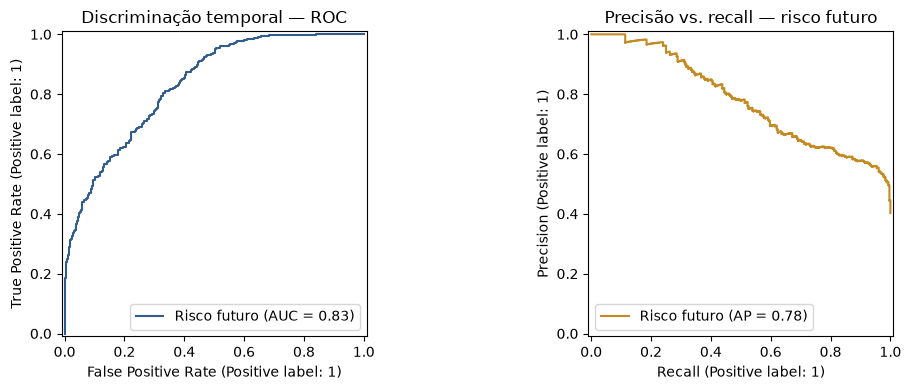

Resposta operacional: os valores acima descrevem a generalização de 2022→2023 para 2023→2024; não representam impacto causal.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_risco, p_risco, name="Risco futuro", ax=axes[0], curve_kwargs={"color": "#315C8D"})
PrecisionRecallDisplay.from_predictions(y_risco, p_risco, name="Risco futuro", ax=axes[1], curve_kwargs={"color": "#C58A22"})
axes[0].set_title("Discriminação temporal — ROC")
axes[1].set_title("Precisão vs. recall — risco futuro")
plt.tight_layout()
plt.show()
print("Resposta operacional: os valores acima descrevem a generalização de 2022→2023 para 2023→2024; não representam impacto causal.")


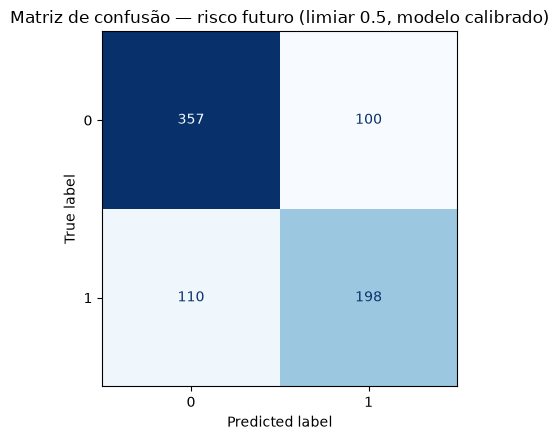

Accuracy: 0.725 | F1-macro: 0.713


In [8]:
previsoes_risco = (p_risco >= 0.5).astype(int)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_risco, previsoes_risco, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusão — risco futuro (limiar 0.5, modelo calibrado)")
plt.tight_layout()
plt.show()

print(f"Accuracy: {metricas_risco['accuracy'].iloc[0]:.3f} | F1-macro: {metricas_risco['f1_macro'].iloc[0]:.3f}")


In [9]:
limiares_risco[["limiar", "taxa_alerta", "precision", "recall", "f1", "falsos_negativos", "falsos_positivos"]].round(3)


,limiar,taxa_alerta,precision,recall,f1,falsos_negativos,falsos_positivos
0,0.2,0.842,0.477,0.997,0.645,1,337
1,0.3,0.710,0.545,0.961,0.696,12,247
2,0.4,0.519,0.620,0.799,0.698,62,151
3,0.5,0.390,0.664,0.643,0.653,110,100
4,0.6,0.288,0.755,0.539,0.629,142,54
5,0.7,0.187,0.846,0.393,0.537,187,22
6,0.8,0.101,0.961,0.240,0.384,234,3


### 2. Incidência de nova defasagem

Este problema é mais próximo de “entrar em risco”, pois remove estudantes já defasados no ano de features. A prevalência, a amostra e a dificuldade estatística mudam; portanto, suas métricas não devem ser comparadas diretamente às do risco futuro.


In [10]:
y_incidencia, p_incidencia, metricas_incidencia, limiares_incidencia, cv_incidencia, vencedor_incidencia = selecionar_e_avaliar(ALVO_INCIDENCIA)
print(f"Vencedor por CV (average_precision, treino 2022): {vencedor_incidencia}")
cv_incidencia.round(4).style.highlight_max(subset=["media_cv"], color="#D9EAD3")


Vencedor por CV (average_precision, treino 2022): Regressão logística


,modelo,media_cv,desvio_cv
0,Regressão logística,0.744300,0.070800
1,Random forest,0.679200,0.064500
2,Gradient boosting,0.573800,0.087800
3,Baseline (prevalência),0.317500,0.003400


In [11]:
tabela_c_incidencia, melhor_c_incidencia, comparacao_incidencia, decisao_incidencia = buscar_e_comparar_c(
    ALVO_INCIDENCIA, metricas_incidencia, vencedor_incidencia
)
print(f"Melhor C por CV (average_precision, treino 2022): {melhor_c_incidencia}")
tabela_c_incidencia.round(4).style.highlight_max(subset=["media_cv"], color="#D9EAD3")

Ganho de pr_auc no teste temporal com C=100.0 sobre C=1.0: -0.0824 (margem mínima para trocar: 0.002). Modelo que fica valendo: default (C=1.0).
Melhor C por CV (average_precision, treino 2022): 100.0


,C,media_cv,desvio_cv
0,100.000000,0.778900,0.095300
1,30.000000,0.777500,0.096200
2,10.000000,0.772100,0.090000
3,3.000000,0.767100,0.085700
4,1.000000,0.744300,0.070800
5,0.300000,0.710700,0.067200
6,0.100000,0.691600,0.044100
7,0.030000,0.623800,0.040700
8,0.010000,0.606400,0.032900


In [ ]:
comparacao_incidencia.round(3)

,Configuracao,Modelo,n,prevalencia,limiar,taxa_alerta,accuracy,precision,recall,f1,f1_macro,roc_auc,pr_auc,brier,falsos_negativos,falsos_positivos
0,C=1.0 (default),Regressão logística (calibrado),370,0.227,0.5,0.222,0.676,0.280,0.274,0.277,0.534,0.693,0.413,0.187,61,59
1,C=100.0 (busca em grade),"Regressão logística (C=100.0, calibrado)",370,0.227,0.5,0.219,0.695,0.321,0.310,0.315,0.559,0.687,0.331,0.187,58,55


**Decisão — incidência de nova defasagem:** a busca em grade preferiu C=100 pelo CV no treino de 2022, com ganho considerável de CV sobre o C=1.0 default. Mas no teste temporal 2023→2024 o pr_auc do modelo tunado **piora** em relação ao default — sinal de que C=100 sobreajusta ao treino de 2022 e não generaliza para o ano seguinte. É exatamente o tipo de caso em que o teste temporal, mesmo sendo confirmatório e não decisório por convenção do projeto, serve de alerta contra uma escolha de hiperparâmetro guiada só pelo CV. Por isso, **o pipeline com C=1.0 (default) continua sendo o modelo oficial de incidência** neste notebook.

**Leitura:** mesma convenção do problema anterior — o CV acima decide o candidato; o teste temporal a seguir só confirma como o vencedor generaliza para 2023→2024.


In [13]:
metricas_incidencia.round(3)


,Modelo,n,prevalencia,limiar,taxa_alerta,accuracy,precision,recall,f1,f1_macro,roc_auc,pr_auc,brier,falsos_negativos,falsos_positivos
0,Regressão logística (calibrado),370,0.227,0.5,0.222,0.676,0.28,0.274,0.277,0.534,0.693,0.413,0.187,61,59


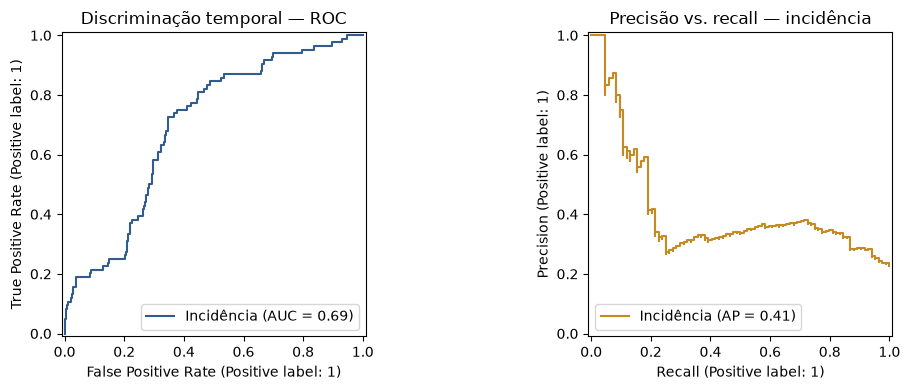

Resposta operacional: o modelo de incidência deve ser usado apenas se o fluxo da Passos Mágicos priorizar prevenção de novos casos.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_incidencia, p_incidencia, name="Incidência", ax=axes[0], curve_kwargs={"color": "#315C8D"})
PrecisionRecallDisplay.from_predictions(y_incidencia, p_incidencia, name="Incidência", ax=axes[1], curve_kwargs={"color": "#C58A22"})
axes[0].set_title("Discriminação temporal — ROC")
axes[1].set_title("Precisão vs. recall — incidência")
plt.tight_layout()
plt.show()
print("Resposta operacional: o modelo de incidência deve ser usado apenas se o fluxo da Passos Mágicos priorizar prevenção de novos casos.")


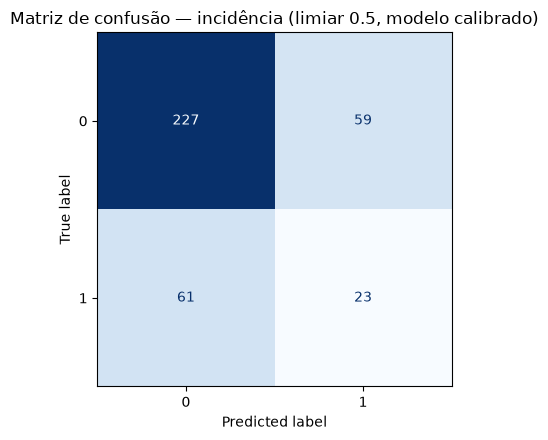

Accuracy: 0.676 | F1-macro: 0.534


In [15]:
previsoes_incidencia = (p_incidencia >= 0.5).astype(int)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_incidencia, previsoes_incidencia, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusão — incidência (limiar 0.5, modelo calibrado)")
plt.tight_layout()
plt.show()

print(f"Accuracy: {metricas_incidencia['accuracy'].iloc[0]:.3f} | F1-macro: {metricas_incidencia['f1_macro'].iloc[0]:.3f}")


In [16]:
limiares_incidencia[["limiar", "taxa_alerta", "precision", "recall", "f1", "falsos_negativos", "falsos_positivos"]].round(3)


,limiar,taxa_alerta,precision,recall,f1,falsos_negativos,falsos_positivos
0,0.2,0.968,0.235,1.000,0.380,0,274
1,0.3,0.681,0.290,0.869,0.435,11,179
2,0.4,0.362,0.366,0.583,0.450,35,85
3,0.5,0.222,0.280,0.274,0.277,61,59
4,0.6,0.051,0.579,0.131,0.214,73,8
5,0.7,0.000,0.000,0.000,0.000,84,0
6,0.8,0.000,0.000,0.000,0.000,84,0


## Interpretação e limites

- O teste é temporal e nunca mistura registros de 2022 e 2023 no treino; essa é a avaliação principal desta base curta.
- O ano de 2024 não entra no treino porque não possui alvo 2025.
- O baseline, a regressão logística, o random forest e o gradient boosting são comparados por CV no treino; não há otimização extensa de hiperparâmetros nem comparação de mais candidatos em cima do teste temporal.
- Um limiar de alerta só deve ser escolhido após definir capacidade de atendimento e custo relativo de falsos negativos e falsos positivos.
- Antes de persistir um modelo para o app, a equipe deve congelar o alvo de produto e executar validação adicional no conjunto de treino, sem usar a coorte de teste para escolher parâmetros.
- A escolha entre os quatro candidatos (baseline, regressão logística, random forest, gradient boosting) usa validação cruzada estratificada dentro do treino (`average_precision`); o teste temporal acima é leitura de confirmação, não critério de seleção.
- As probabilidades do modelo vencedor são calibradas (`CalibratedClassifierCV`, sigmoid, 5 folds) só com dados de treino, antes de tocar a coorte de teste.


## Próximos passos

1. Definir com o grupo se o aplicativo exibirá risco futuro, incidência ou ambos.
2. Definir capacidade operacional e regra para escolha do limiar de alerta.
3. ~~Buscar hiperparâmetros do candidato vencedor~~ **Concluído:** busca em grade do `C` da regressão logística (única candidata tunada, por ter vencido a seleção nos dois problemas), por CV estratificado só no treino de 2022 (`buscar_hiperparametros_logistico`). Nos dois problemas o ganho no teste temporal 2023→2024 não justificou trocar do C=1.0 default (ver comparação nas seções de resultados) — o pipeline oficial permanece com C=1.0.
4. Reavaliar a calibração a cada novo candidato vencedor ou novo ciclo de dados — o Brier score já usa `CalibratedClassifierCV` ajustado só no treino, mas deve ser conferido sempre que o modelo mudar.
5. Persistir o pipeline aprovado (C=1.0, calibrado) com `joblib` em `models/`, com metadados de versão, e construir o app Streamlit — próximo passo real do pipeline de modelagem.
6. Monitorar deriva dos indicadores de entrada (comparar a distribuição de IAN, IDA, IEG e demais features a cada nova edição da PEDE com a distribuição usada no treino) e retreinar o modelo periodicamente quando uma nova edição da PEDE entrar na base.
